## Simulate the model under constant gain learning + Lasso

In [19]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [20]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
constant_gain = 0.01  # constant gain parameter for learning
lambda_lasso = 0.01  # Lasso penalty parameter
print(f"w: {w}, kappa: {kappa}")

w: 0.04272559525665953, kappa: 0.9581307815062262


In [21]:
def lasso_from_beta_ols(beta_ols, lambda_param):
    """
    Apply Lasso shrinkage to OLS coefficients.
    
    Parameters:
    beta_ols (np.ndarray): OLS coefficients.
    lambda_param (float): Regularization parameter.
    
    Returns:
    np.ndarray: Lasso-shrunken coefficients.
    """
    return np.sign(beta_ols) * np.maximum(np.abs(beta_ols) - lambda_param, 0)

## Univariate case

In [22]:
# Initialization
T = 100 # number of time periods
x = np.random.normal(0, sigma_x, T) # observable variable
r = np.zeros(T) # actual gross returns
beta = np.zeros(T) # coefficient for the observable variable
beta_lasso = np.zeros(T) # lasso-shrunken coefficient for the observable variable
M = np.zeros(T)

#Starting values
beta[0] = np.random.normal(0, 0.001) #small perturbation around REE
beta_lasso[0] = beta[0]
beta[1] = np.random.normal(0, 0.001)
beta_lasso[1] = beta[1]
M[0] = sigma_x ** 2 # initial variance of the observable variable 
r[1] = np.random.normal(0, 0.0001) 

for t in range(2, T):
    # update M
    M[t-1] = M[t-2] + (x[t-2]**2 - M[t-2]) * constant_gain
    # update beta using RLS
    beta[t] = beta[t-1] + constant_gain * ( M[t-1]) ** -1 * (x[t-2] * r[t-1] - x[t-2]**2 * beta[t-1])
    # apply lasso shrinkage
    beta_lasso[t] = lasso_from_beta_ols(beta[t], lambda_lasso)
    # compute expected returns
    r[t] = np.log(1 - kappa * np.exp(w * np.tanh(beta_lasso[t-1] * x[t-1] / w))) - np.log(1 - kappa * np.exp(w * np.tanh(beta_lasso[t] * x[t] / w))) + np.random.normal(0, sigma)


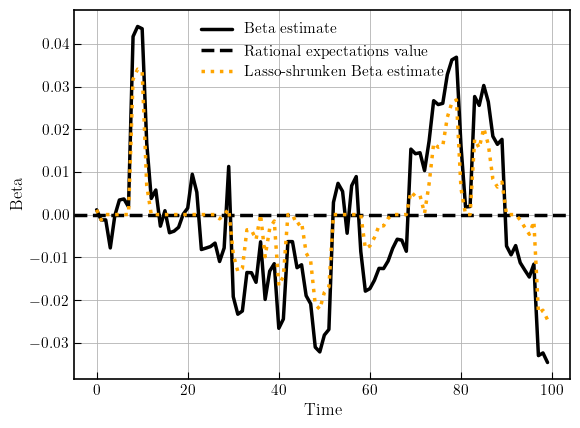

In [23]:
#visualize beta coefficient over time
fig, ax = plt.subplots()
ax.plot(beta, label='Beta estimate')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
#add lasso beta
ax.plot(beta_lasso, label='Lasso-shrunken Beta estimate', linestyle=':', color='orange')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

## Multivariate case (2 is enough)

In [24]:
def multivariate_CGL_lasso(T, K, sigma_x, sigma, kappa, w, lambda_lasso):
    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta = np.zeros((T, K, 1)) # coefficients for the observable variables
    beta_lasso = np.zeros((T, K, 1)) # lasso-shrunken coefficients for the observable variables
    M = np.zeros((T, K, K))
    r = np.zeros(T)

    #Starting values
    beta[0, :, 0] = np.random.normal(0, 0.001, K) #small perturbation around REE
    beta[1, :, 0] = np.random.normal(0, 0.001, K)
    M[0, :, :] = np.eye(K) * sigma_x ** 2 # initial variance of the observable variables 
    r[1] = np.random.normal(0, 0.0001)

    for t in range(2, T):
        # update M
        M[t-1, :, :] = M[t-2, :, :] + (np.outer(x[t-2, :], x[t-2, :]) - M[t-2, :, :]) * constant_gain
        # update beta using RLS
        beta[t, :, 0] = beta[t-1, :, 0] + constant_gain * np.linalg.inv( M[t-1, :, :]) @ (x[t-2, :].reshape(-1, 1) * r[t-1] - (x[t-2, :].reshape(-1, 1) @ x[t-2, :].reshape(1, -1)) @ beta[t-1, :, 0].reshape(-1, 1)).flatten()
        # compute expected returns
        beta_lasso[t, :, 0] = lasso_from_beta_ols(beta[t, :, 0], lambda_lasso)
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta, r, beta_lasso, x

In [25]:
beta, r, beta_lasso, x = multivariate_CGL_lasso(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_63276/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


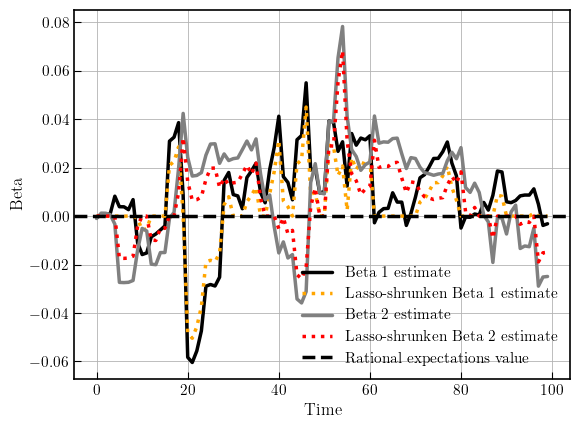

In [26]:
#visualzie the two betas over time
fig, ax = plt.subplots()
ax.plot(beta[:, 0, 0], label='Beta 1 estimate')
ax.plot(beta_lasso[:, 0, 0], label='Lasso-shrunken Beta 1 estimate', linestyle=':', color='orange')
ax.plot(beta[:, 1, 0], label='Beta 2 estimate', color = 'gray')
ax.plot(beta_lasso[:, 1, 0], label='Lasso-shrunken Beta 2 estimate', linestyle=':', color='red')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [27]:
## Check with multiple stochastic seeds to ensure robustness
num_simulations = 10
all_betas = []
all_betas_lasso = []
for sim in range(num_simulations):
    np.random.seed(sim)
    beta, r, beta_lasso, x = multivariate_CGL_lasso(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)
    all_betas.append(beta)
    all_betas_lasso.append(beta_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_63276/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


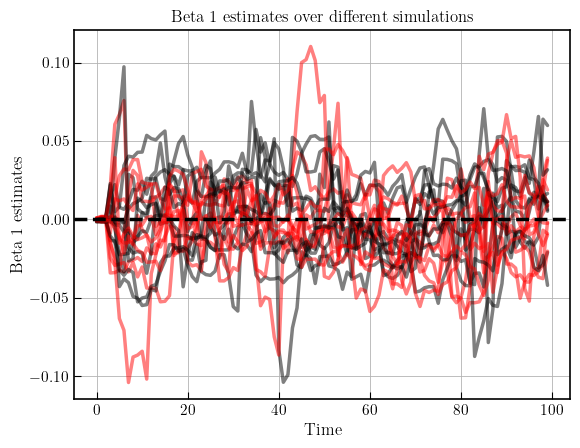

In [28]:
#visualization of coefficients over seeds
fig, ax = plt.subplots()
for sim in range(num_simulations):
    ax.plot(all_betas[sim][:, 0, 0], alpha=0.5, label = 'beta_1')
    ax.plot(all_betas[sim][:, 1, 0], alpha=0.5, color = 'red', label = 'beta_2')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta 1 estimates')
ax.set_xlabel('Time')
ax.set_title('Beta 1 estimates over different simulations')
plt.show()

In [29]:
#generate long time series for K = 20 and T = 10000
beta, r, beta_lasso, x = multivariate_CGL_lasso(T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_63276/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


## Simulate rolling window estimation first with LASSO, then with OLS.

In [30]:
from sklearn.linear_model import Lasso

In [31]:
def multivariate_CGL_offline_lasso(T, K, sigma_x, sigma, kappa, w, rolling_window_size = 30, lambda_lasso = 0.01, correct_with_tanh = True):
    
    #assert that rolling_window_size < T otherwise offline estimation is not possible
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    rng = np.random.default_rng(12345)
    x = rng.normal(0, sigma_x, size=(T, K)) # observable variables
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    #Starting values
    r_offline[1:rolling_window_size+1] = rng.normal(0, 0.0001, rolling_window_size)



    for t in range(rolling_window_size+1, T):
        #generate x_current, up and including t-2
        x_current = x[t-rolling_window_size-1:t-1,:] #(x0, ... x299)
        r_offline_current = r_offline[t-rolling_window_size:t] # (r1, ... r300)
        beta_offline[t] = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42).fit(x_current, r_offline_current).coef_.reshape(-1,1)
        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)))) - np.log(1 - kappa * np.exp((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)))) + np.random.normal(0, sigma)).item() #r_301
    
    return beta_offline, r_offline, x

In [32]:
beta_offline, r_offline, x = multivariate_CGL_offline_lasso(T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, rolling_window_size=300, lambda_lasso=0.00001, correct_with_tanh=False)

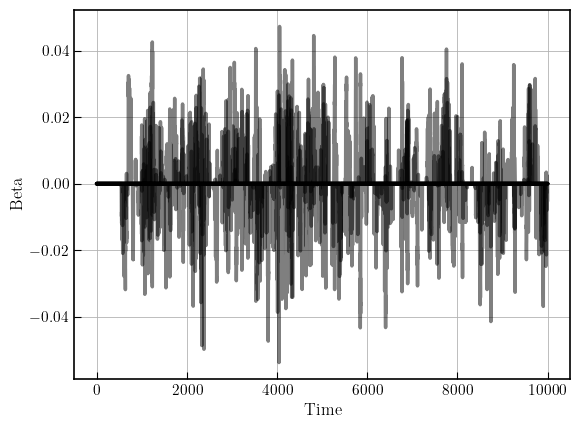

In [33]:
# visualize the lasso offline LASSO estimates
fig, ax = plt.subplots()
for k in range(beta_offline.shape[1]):
    ax.plot(beta_offline[:, k, 0], alpha = 0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
plt.show()

In [34]:
#create a dataset with x and r
#generate fictituous dates
import pandas as pd
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')
data = pd.DataFrame(data=x, index=dates, columns=[f'x_{i+1}' for i in range(x.shape[1])])
data['r'] = r_offline

#loop to save the betas
for i in range(beta_offline.shape[1]):
    data[f'beta_{i+1}'] = beta_offline[:, i, 0]

data.to_csv('simulation_data_offline_lasso.csv')


## Monte Carlo check: simulated vs theoretical distribution of $\beta_t$ (rolling window)

For the rolling-window OLS estimator with window size $W$, the effective learning gain is $1/W$.
By analogy with the constant-gain formula (where gain $= \gamma$), the stationary distribution of the pre-Lasso OLS coefficient is approximately:

$$\beta_t^{\text{OLS}} \approx \mathcal{N}\!\left(0,\; \frac{\sigma^2(1-\kappa)}{2\,W\,\sigma_x^2}\right)$$

After Lasso soft-thresholding with penalty $\lambda$, the distribution of $\hat\beta^{\text{Lasso}}$ becomes a mixture: a point mass at 0 (for draws with $|\beta^{\text{OLS}}| \leq \lambda$) and a shifted normal for $|\beta^{\text{OLS}}| > \lambda$.


Window size W = 200,  lambda = 0.01
Draws        : 292000
OLS  sim mean: -0.000092
OLS  sim var : 5.7050e-04   (theory: 1.0467e-04)
Lasso sim var: 2.8522e-04


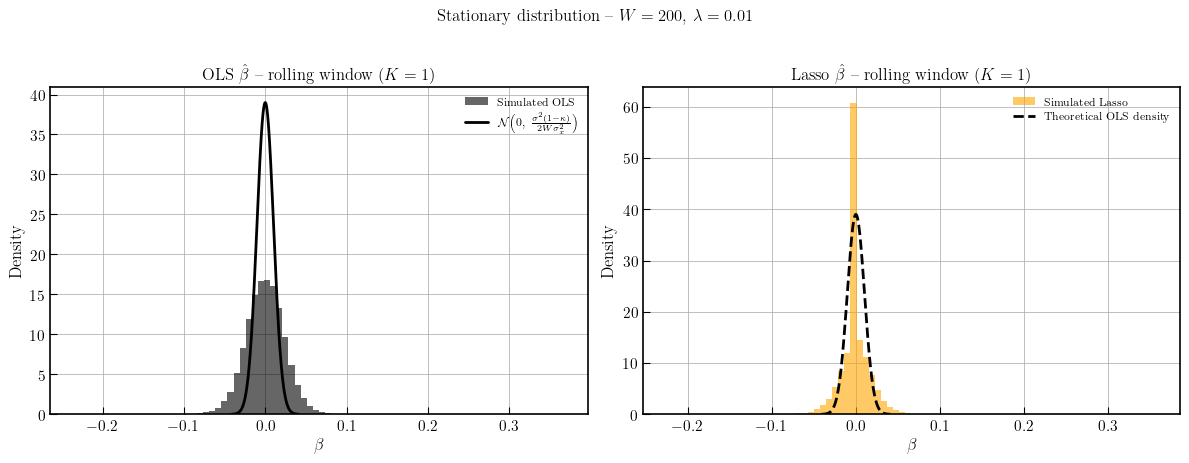

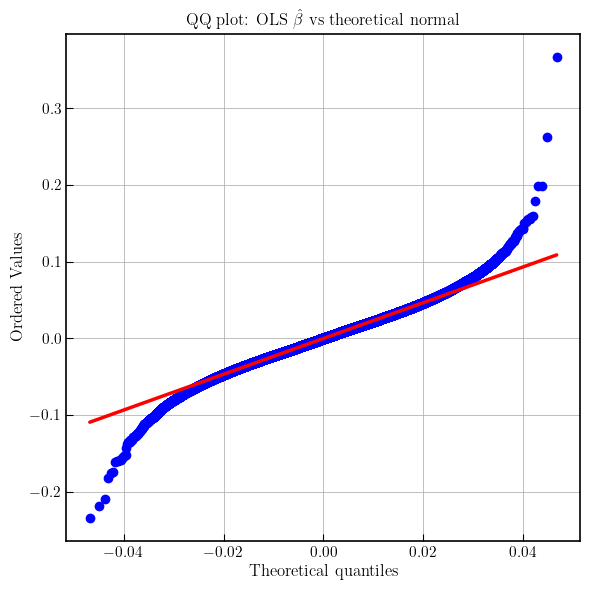


KS statistic: 0.1888
KS p-value  : 0.0000


In [35]:

from math import sqrt, pi
from scipy import stats

def theoretical_beta_var_window(window_size, sigma, sigma_x, kappa):
    """Theoretical variance of the rolling-window OLS beta (effective gain = 1/W)."""
    return (1.0 / window_size) * sigma**2 * (1.0 - kappa) / (2.0 * sigma_x**2)


def offline_ols_lasso_mc(T, sigma_x, sigma, kappa, w, window_size, lambda_lasso, seed=None):
    """Univariate (K=1) rolling-window OLS + Lasso for Monte Carlo distribution check.

    Returns ols_betas and lasso_betas (1-D arrays of length T).
    The model evolves using the Lasso beta in the pricing equation,
    so the stationary distribution reflects the actual equilibrium.
    """
    rng = np.random.default_rng(seed)
    x = rng.normal(0.0, sigma_x, size=T)
    ols_betas = np.zeros(T)
    lasso_betas = np.zeros(T)
    r = np.zeros(T)
    r[1:window_size + 1] = rng.normal(0.0, 1e-4, window_size)

    def g(b, xv):
        return np.log(1.0 - kappa * np.exp(w * np.tanh(b * xv / w)))

    for t in range(window_size + 1, T):
        xw = x[t - window_size - 1: t - 1]      # window_size predictors
        rw = r[t - window_size: t]               # window_size return targets
        # univariate OLS: beta = (x'r) / (x'x)
        ols_betas[t] = float(xw @ rw) / (float(xw @ xw) + 1e-12)
        lasso_betas[t] = lasso_from_beta_ols(ols_betas[t], lambda_lasso)
        r[t] = (g(lasso_betas[t - 1], x[t - 1])
                - g(lasso_betas[t], x[t])
                + rng.normal(0.0, sigma))

    return ols_betas, lasso_betas


# ---- Monte Carlo settings ----
N_paths_mc = 200
T_mc = 8000
window_size_mc = 200
burn_mc = window_size_mc + 500
thin_mc = 5

ols_draws, lasso_draws = [], []
for n in range(N_paths_mc):
    b_ols, b_lasso = offline_ols_lasso_mc(
        T=T_mc, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w,
        window_size=window_size_mc, lambda_lasso=lambda_lasso, seed=3000 + n
    )
    ols_draws.append(b_ols[burn_mc::thin_mc])
    lasso_draws.append(b_lasso[burn_mc::thin_mc])

ols_draws = np.concatenate(ols_draws)
lasso_draws = np.concatenate(lasso_draws)

var_th = theoretical_beta_var_window(window_size_mc, sigma, sigma_x, kappa)
sd_th = sqrt(var_th)

print(f"Window size W = {window_size_mc},  lambda = {lambda_lasso}")
print(f"Draws        : {ols_draws.size}")
print(f"OLS  sim mean: {ols_draws.mean():.6f}")
print(f"OLS  sim var : {ols_draws.var(ddof=1):.4e}   (theory: {var_th:.4e})")
print(f"Lasso sim var: {lasso_draws.var(ddof=1):.4e}")

# ---- Plots ----
xs = np.linspace(-4 * sd_th, 4 * sd_th, 400)
pdf = (1.0 / (sd_th * sqrt(2 * pi))) * np.exp(-0.5 * (xs / sd_th) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(ols_draws, bins=80, density=True, alpha=0.6, label="Simulated OLS")
axes[0].plot(xs, pdf, lw=2,
             label=r"$\mathcal{N}\!\left(0,\;\frac{\sigma^2(1-\kappa)}{2W\sigma_x^2}\right)$")
axes[0].set_title(r"OLS $\hat\beta$ -- rolling window ($K=1$)")
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

axes[1].hist(lasso_draws, bins=80, density=True, alpha=0.6, color="orange",
             label="Simulated Lasso")
axes[1].plot(xs, pdf, lw=2, linestyle="--", label="Theoretical OLS density")
axes[1].set_title(r"Lasso $\hat\beta$ -- rolling window ($K=1$)")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.suptitle(
    f"Stationary distribution -- $W={window_size_mc}$, $\\lambda={lambda_lasso}$",
    y=1.02
)
plt.tight_layout()
plt.show()

# ---- QQ plot and KS test (OLS only -- Lasso has a point mass at 0) ----
fig = plt.figure(figsize=(6, 6))
stats.probplot(ols_draws, dist=stats.norm(loc=0, scale=sd_th), plot=plt)
plt.title(r"QQ plot: OLS $\hat{\beta}$ vs theoretical normal")
plt.tight_layout()
plt.show()

ks = stats.kstest(ols_draws, "norm", args=(0.0, sd_th))
print(f"\nKS statistic: {ks.statistic:.4f}")
print(f"KS p-value  : {ks.pvalue:.4f}")
